# Build Dataset Generation Config

This notebook processes official energy data from:

- EPE (Empresa de Pesquisa Energética)
- ANEEL (Agência Nacional de Energia Elétrica)

The goal is to generate the probabilistic configuration files used by the synthetic dataset generator.

Outputs:
- consumption_profiles.csv
- energy_source_distribution.csv
- company_size_distribution_by_usage.csv
- usage_distribution_by_state.csv
- seasonality_state_class_month.csv

Clona Projeto direto do github para facilitar

In [1]:
# Mapping Portuguese categories to standardized English labels
category_map = {
    'comercial': 'comercial',
    'industrial': 'industrial',
    'outros': 'outros',
    'residencial': 'residencial',
    'rural': 'rural',
    'Comercial': 'comercial',
    'Industrial': 'industrial',
    'Outros': 'outros',
    'Residencial': 'residencial',
    'Rural': 'rural'
}

# # !git clone https://github.com/carbon-footprint-analysis/carbon-footprint-analysis.git

importa dados oficiais da empresa de pesquisa energetica e faz EDA + ETL para criar o dataset sintetico ainda !

Abaixo e o data set de consumo por categoria e estado o consumo esta em MW mas abaixo sera convertido para kwh

In [2]:
import pandas as pd

epe = pd.read_csv('../data/raw/epe_industrial_consumption_by_state.csv',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [3]:
epe.head()

,Coluna1,DataExcel,SetorIndustrial,UF,Regiao,Consumo,DataVersao
0,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,23/02/2026
1,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,23/02/2026
2,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,23/02/2026
3,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,23/02/2026
4,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,23/02/2026


In [4]:
epe['DataExcel'] = pd.to_datetime(epe['DataExcel'], dayfirst=True)

In [5]:
epe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135676 entries, 0 to 135675
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Coluna1          135676 non-null  int64         
 1   DataExcel        135676 non-null  datetime64[ns]
 2   SetorIndustrial  135676 non-null  object        
 3   UF               135676 non-null  object        
 4   Regiao           135676 non-null  object        
 5   Consumo          135676 non-null  float64       
 6   DataVersao       135676 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 7.2+ MB


In [6]:
epe['SetorIndustrial'].unique()

array(['05 - EXTRAÇÃO DE CARVÃO MINERAL',
       '06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL',
       '07 - EXTRAÇÃO DE MINERAIS METÁLICOS',
       '08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS',
       '09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS',
       '10 - FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS',
       '11 - FABRICAÇÃO DE BEBIDAS',
       '12 - FABRICAÇÃO DE PRODUTOS DO FUMO',
       '13 - FABRICAÇÃO DE PRODUTOS TÊXTEIS',
       '14 - CONFECÇÃO DE ARTIGOS DO VESTUÁRIO E ACESSÓRIOS',
       '15 - PREPARAÇÃO DE COUROS E FABRICAÇÃO DE ARTEFATOS DE COURO, ARTIGOS PARA VIAGEM E CALÇADOS',
       '16 - FABRICAÇÃO DE PRODUTOS DE MADEIRA',
       '17 - FABRICAÇÃO DE CELULOSE, PAPEL E PRODUTOS DE PAPEL',
       '18 - IMPRESSÃO E REPRODUÇÃO DE GRAVAÇÕES',
       '19 - FABRICAÇÃO DE COQUE, DE PRODUTOS DERIVADOS DO PETRÓLEO E DE BIOCOMBUSTÍVEIS',
       '20 - FABRICAÇÃO DE PRODUTOS QUÍMICOS',
       '21 - FABRICAÇÃO DE PRODUTOS FARMOQUÍMICOS E FARMACÊUTICOS',
       '22 - FABRICAÇÃO DE PRODUTOS DE

In [7]:
df = epe.copy()

In [8]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [9]:
df_2025 = df[df['year'] == 2025].copy()
df_2025.drop(columns=['DataVersao', 'DataExcel'], inplace=True)

In [10]:
df_2025.head(5)

,Coluna1,SetorIndustrial,UF,Regiao,Consumo,year,month
0,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,2025,12
1,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,2025,12
2,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,2025,12
3,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,2025,12
4,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,2025,12


In [11]:
df_grouped = df.groupby('SetorIndustrial')['Consumo'].mean().reset_index()

In [12]:
df_grouped = df_grouped.rename(columns={'Consumo':'Consumo_MWh'})

In [13]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885


In [14]:
df_grouped['Consumo_kWh'] = (df_grouped['Consumo_MWh']) * 1000

In [15]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [16]:
df_grouped.to_csv('../data/processed/media_consumo_indutria_2025.csv')

Abertura do dados oficial consumo mensal por categoria a escala de energia esta em MW mas sera convertido em kwh.

Tambem foi feito o EDA e ETL para criação do dataset sintetico !

In [17]:
import pandas as pd

epe_categoria = pd.read_csv('../data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [18]:
df_2025 = df[df['year'] == 2025].copy()
df_2025.drop(columns=['DataVersao', 'DataExcel'], inplace=True)

In [19]:
epe_categoria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59243 entries, 0 to 59242
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Data            59243 non-null  int64 
 1   DataExcel       59243 non-null  object
 2   UF              59243 non-null  object
 3   Regiao          59243 non-null  object
 4   Sistema         59243 non-null  object
 5   Classe          59243 non-null  object
 6   TipoConsumidor  59243 non-null  object
 7   Consumo         59243 non-null  object
 8   Consumidores    59243 non-null  object
 9   DataVersao      59243 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.5+ MB


In [20]:
epe_categoria['DataExcel'] = pd.to_datetime(epe_categoria['DataExcel'], dayfirst=True)

In [21]:
df = epe_categoria.copy()

In [22]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [23]:
df_2025 = df[df['year'] == 2025]

In [24]:
df_2025['Consumo'] = (
    df_2025['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_2025['Consumidores'] = (
    df_2025['Consumidores']
    .astype(str)
    .str.replace('.', '', regex=False)
    .astype(float)
)

C:\Users\anlur\AppData\Local\Temp\ipykernel_20968\3063530973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumo'] = (
C:\Users\anlur\AppData\Local\Temp\ipykernel_20968\3063530973.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumidores'] = (


In [25]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 0 to 3327
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            3328 non-null   int64         
 1   DataExcel       3328 non-null   datetime64[ns]
 2   UF              3328 non-null   object        
 3   Regiao          3328 non-null   object        
 4   Sistema         3328 non-null   object        
 5   Classe          3328 non-null   object        
 6   TipoConsumidor  3328 non-null   object        
 7   Consumo         3328 non-null   float64       
 8   Consumidores    3328 non-null   float64       
 9   DataVersao      3328 non-null   object        
 10  year            3328 non-null   int32         
 11  month           3328 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(6)
memory usage: 312.0+ KB


In [26]:
df_2025.head()

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478.0,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4.0,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382.0,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8862.0,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125.0,23/02/2026,2025,12


In [27]:
df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)

C:\Users\anlur\AppData\Local\Temp\ipykernel_20968\3578452241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)


In [28]:
df_2025 = df_2025.rename(columns={'Consumo':'Consumo_MWh'})

In [29]:
df_simplificado = (
    df_2025
    .groupby('Classe')
    .agg({
        'Consumo_MWh': 'sum',
        'Consumidores': 'sum'
    })
)

df_simplificado['consumo_medio_MWh'] = df_simplificado['Consumo_MWh'] / df_simplificado['Consumidores']

df_simplificado = df_simplificado.sort_values('Consumo_MWh', ascending=False)

In [30]:
df_simplificado['Consumo_kWh'] = (df_simplificado['Consumo_MWh']) * 1000
df_simplificado['consumo_medio_KWh'] = (df_simplificado['consumo_medio_MWh']) * 1000

In [31]:
df_simplificado = df_simplificado[[
    'Consumidores',
    'Consumo_MWh',
    'Consumo_kWh',
    'consumo_medio_MWh',
    'consumo_medio_KWh'
]]

In [32]:
df_simplificado

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [33]:
df_simplificado.to_csv('../data/processed/consumo_medio_categoria_2025.csv')

Verificando a sanidade dos dados

In [34]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [35]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SetorIndustrial  37 non-null     object 
 1   Consumo_MWh      37 non-null     float64
 2   Consumo_kWh      37 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1020.0+ bytes


In [36]:
df_simplificado.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [37]:
df_simplificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Industrial to Rural
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Consumidores       5 non-null      float64
 1   Consumo_MWh        5 non-null      float64
 2   Consumo_kWh        5 non-null      float64
 3   consumo_medio_MWh  5 non-null      float64
 4   consumo_medio_KWh  5 non-null      float64
dtypes: float64(5)
memory usage: 240.0+ bytes


Criação do consumption_profile.csv

In [38]:
df_profiles = df_simplificado.copy()

In [39]:
df_profiles.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [40]:
def get_sigma(classe):
    if classe in ['Industrial', 'industrial']:
        return 0.6
    elif classe in ['Comercial', 'comercial']:
        return 0.4
    elif classe in ['Residencial', 'residencial']:
        return 0.3
    else:
        return 0.35

df_profiles['sigma'] = df_profiles.index.map(get_sigma)

In [41]:
map_usage = {
    'Industrial': 'industrial',
    'Comercial':  'comercial',
    'Residencial': 'residencial',
    'Rural':      'rural',
    'Outros':     'outros'
}

df_profiles['usage_type'] = df_profiles.index.map(map_usage)

In [42]:
import numpy as np

df_profiles['mu'] = np.log(df_profiles['consumo_medio_KWh'])

In [43]:
df_final = df_profiles.copy()
df_final['fuel_type'] = 'electric'
df_final['distribution_type'] = 'lognormal'
df_final['param_1'] = df_profiles['mu']
df_final['param_2'] = df_profiles['sigma']
df_final['param_1_name'] = 'mu'
df_final['param_2_name'] = 'sigma'
df_final['unit'] = 'kWh'
df_final['is_energy_based'] = True

In [44]:
df_final.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh,sigma,usage_type,mu,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,,,,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245,0.60,industrial,10.512328,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142,0.30,residencial,5.183939,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719,0.40,comercial,7.231606,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995,0.35,outros,8.490598,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246,0.35,rural,6.509096,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [45]:
df_export = df_final[[
    'usage_type',
    'fuel_type',
    'distribution_type',
    'param_1',
    'param_2',
    'param_1_name',
    'param_2_name',
    'unit',
    'is_energy_based'
]].copy()

In [46]:
df_export.head()

,usage_type,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,
Industrial,industrial,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,residencial,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,comercial,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,outros,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,rural,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [47]:
df_export.to_csv('../data/processed/v2_consumption_profiles.csv', index=False)

transformar config em dados sinteticos reais

carergando profile

In [48]:
import pandas as pd
import numpy as np

profiles = pd.read_csv('../data/processed/v2_consumption_profiles.csv')

gerar função

In [49]:
def generate_consumption(profile_row):

    if profile_row['distribution_type'] == 'lognormal':
        mu = profile_row['param_1']
        sigma = profile_row['param_2']

        value = np.random.lognormal(mu, sigma)

        # LIMITADOR
        max_value = 10 * np.exp(mu)
        value = min(value, max_value)

        return value

    else:
        raise ValueError("Distribuição não suportada")

gerar evento

In [50]:
usage_probs = {
    'residencial': 0.6,
    'comercial': 0.2,
    'industrial': 0.1,
    'rural': 0.05,
    'outros': 0.05
}

In [51]:
def generate_event(profiles):

    weights = profiles['usage_type'].map(usage_probs)

    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption
    }

gerar dataset

In [52]:
def generate_dataset(n, profiles):
    data = []

    for _ in range(n):
        event = generate_event(profiles)
        data.append(event)

    return pd.DataFrame(data)

test

In [53]:
df = generate_dataset(10000, profiles)

In [54]:
df.head()

,usage_type,fuel_type,energy_kwh
0,residencial,electric,281.827576
1,comercial,electric,1070.009623
2,comercial,electric,1288.885462
3,residencial,electric,123.117764
4,comercial,electric,1515.645628


In [55]:
df.to_csv('df_gerado_teste.csv')

In [56]:
df['usage_type'].value_counts(normalize=True)

usage_type
residencial    0.6054
comercial      0.1943
industrial     0.1023
rural          0.0494
outros         0.0486
Name: proportion, dtype: float64

In [57]:
df.groupby('usage_type')['energy_kwh'].describe()

,count,mean,std,min,25%,50%,75%,max
usage_type,,,,,,,,
comercial,1943.0,1497.966938,643.552829,388.930085,1051.467855,1375.799344,1821.097977,8279.706599
industrial,1023.0,45443.961080,28123.831985,5373.537716,26083.610904,38866.738822,56690.928785,222887.349466
outros,486.0,5091.574645,1841.380621,1304.112649,3766.109349,4799.785458,6112.765696,14399.918086
residencial,6054.0,187.212095,56.059746,59.406188,147.303752,179.814558,219.560806,565.816073
rural,494.0,697.518023,254.005979,233.939784,513.505814,664.646804,826.773301,1810.082224


In [58]:
df['energy_kwh'].max()

np.float64(222887.3494661831)

In [59]:
(df['energy_kwh'] < 0).sum()

np.int64(0)

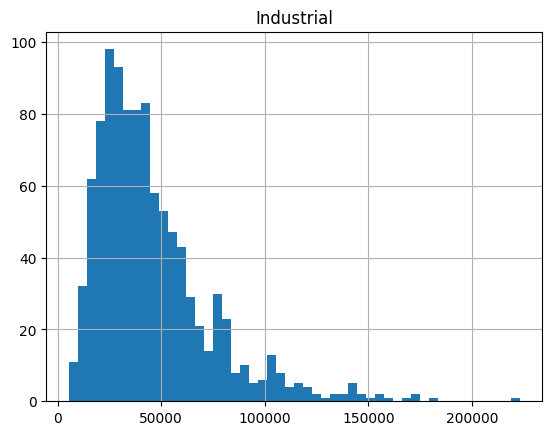

In [60]:
import matplotlib.pyplot as plt

df[df['usage_type']=='industrial']['energy_kwh'].hist(bins=50)
plt.title('Industrial')
plt.show()

criando o energy_source_distribution.csv

In [61]:
df_aneel = pd.read_csv('../data/raw/aneel_generation.csv',
                       encoding='latin-1',
                       sep=';',
                       decimal=',')

In [62]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DatGeracaoConjuntoDados  495 non-null    object 
 1   SigTipoGeracao           495 non-null    object 
 2   QtdUsinasPeriodo         495 non-null    int64  
 3   MdaPotenciaInstaladaKW   495 non-null    float64
 4   MesReferencia            495 non-null    int64  
 5   AnoReferencia            495 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 23.3+ KB


In [63]:
df_aneel.head()

,DatGeracaoConjuntoDados,SigTipoGeracao,QtdUsinasPeriodo,MdaPotenciaInstaladaKW,MesReferencia,AnoReferencia
0,2026-03-01,CGH,0,0.0,12,2001
1,2026-03-01,EOL,7,21000.0,12,2001
2,2026-03-01,PCH,303,855000.0,12,2001
3,2026-03-01,UFV,0,0.0,12,2001
4,2026-03-01,UHE,133,61554000.0,12,2001


In [64]:
df_aneel['AnoReferencia'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025])

In [65]:
df_aneel = df_aneel[df_aneel['AnoReferencia']==2025]

In [66]:
df_aneel['SigTipoGeracao'].unique()

array(['EOL', 'CGH', 'UFV', 'PCH', 'UHE', 'UTE', 'UTN'], dtype=object)

In [67]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum()

In [68]:
df_grouped.head()

SigTipoGeracao
CGH    3.577829e+06
EOL    1.360294e+08
PCH    2.382840e+07
UFV    7.451254e+07
UHE    4.128522e+08
Name: MdaPotenciaInstaladaKW, dtype: float64

converter para probabilidade

In [69]:
df_dist = df_grouped / df_grouped.sum()

transformar e dataframe

In [70]:
df_dist.info()

<class 'pandas.core.series.Series'>
Index: 7 entries, CGH to UTN
Series name: MdaPotenciaInstaladaKW
Non-Null Count  Dtype  
--------------  -----  
7 non-null      float64
dtypes: float64(1)
memory usage: 112.0+ bytes


In [71]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum().reset_index()

df_grouped.columns = ['energy_source', 'total_generation']

In [72]:
df_grouped['probability'] = df_grouped['total_generation'] / df_grouped['total_generation'].sum()

df_dist = df_grouped[['energy_source', 'probability']]
df_dist = df_dist.copy()

In [73]:
df_dist.head()

,energy_source,probability
0,CGH,0.004194
1,EOL,0.159455
2,PCH,0.027932
3,UFV,0.087344
4,UHE,0.483948


In [74]:
df_dist['probability'].sum()

np.float64(1.0)

In [75]:
map_sources = {
    'UHE': 'hidrelétrica',      # Hidrelétrica grande
    'PCH': 'hidrelétrica',      # Pequena central hidrelétrica
    'CGH': 'hidrelétrica',      # Central geradora hidráulica

    'EOL': 'eólica',       # Eólica

    'UFV': 'solar',      # Solar fotovoltaica

    # se aparecer depois:
    'UTE': 'térmica',    # termoelétrica (genérico)
    'UTN': 'nuclear',    # nuclear
}
df_dist['energy_source'] = df_dist['energy_source'].map(map_sources)

In [76]:
df_dist = df_dist.groupby('energy_source')['probability'].sum().reset_index()

In [77]:
df_dist['probability'] = df_dist['probability'] / df_dist['probability'].sum()

In [78]:
df_dist = df_dist.sort_values('probability', ascending=False)

In [79]:
df_dist

,energy_source,probability
1,hidrelétrica,0.516074
4,térmica,0.227796
0,eólica,0.159455
3,solar,0.087344
2,nuclear,0.009331


In [80]:
df_dist.to_csv('../data/processed/v2_energy_source_distribution.csv')

Inserir a emissão co2

In [81]:
emission_factors = pd.read_csv('../data/processed/v2_energy_source_emission_factors.csv')

In [82]:
def calculate_emission(energy_kwh, energy_source, emission_df):

    row = emission_df.loc[
        emission_df['energy_source'] == energy_source
    ]

    if row.empty:
        raise ValueError(f"Fonte não encontrada: {energy_source}")

    factor = row['emission_factor'].values[0]

    return energy_kwh * factor

In [83]:
def sample_energy_source(dist_df):
    return dist_df.sample(1, weights=dist_df['probability']).iloc[0]['energy_source']

In [84]:
def normalize_usage_types(series):

    mapping = {
        'residencial': 'residencial',
        'rural': 'rural',
        'outros': 'outros',
        'industrial': 'industrial',
        'comercial': 'comercial'
    }

    return (
        series
        .str.strip()
        .str.lower()
        .replace(mapping)
    )

In [85]:
def generate_event(profiles, energy_dist, emission_df):

    usage_types = normalize_usage_types(profiles['usage_type'])

    weights = usage_types.map(usage_probs)

    if weights.sum() == 0:
        raise ValueError("usage_probs não corresponde aos usage_type do profile")

    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    energy_source = sample_energy_source(energy_dist)

    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [86]:
import pandas as pd
profiles = pd.read_csv('../data/processed/v2_consumption_profiles.csv')

energy_dist = pd.read_csv('../data/processed/v2_energy_source_distribution.csv')

emission_df = pd.read_csv('../data/processed/v2_energy_source_emission_factors.csv')

In [87]:
event = generate_event(profiles, energy_dist, emission_df)
event

{'usage_type': 'comercial',
 'fuel_type': 'electric',
 'energy_kwh': 961.3333276908375,
 'energy_source': 'nuclear',
 'co2_emission': np.float64(9.613333276908374)}

In [88]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [89]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,energy_kwh,co2_emission
count,10000.000000,10000.000000
mean,4987.311937,765.427074
std,15675.284531,4730.530136
min,54.818069,0.635473
25%,167.226029,3.315746
50%,238.412391,12.869768
75%,1397.833746,105.332059
max,367659.792448,111727.057345


In [90]:
df.head()

,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,residencial,electric,242.144081,eólica,2.421441
1,comercial,electric,1075.093076,hidrelétrica,21.501862
2,residencial,electric,129.655648,hidrelétrica,2.593113
3,comercial,electric,1792.815681,eólica,17.928157
4,residencial,electric,214.982937,hidrelétrica,4.299659


Adicionando ID e datas

In [91]:
company_id = f"C{np.random.randint(1000,9999)}"

In [92]:
date = pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0, 365), unit='D')

In [93]:
states = [
'SP','MG','RJ','BA','PR','RS','SC','GO','PE','CE',
'PA','MT','ES','DF','MS','MA','RN','PB','AL','PI',
'RO','SE','TO','AC','AP','RR','AM'
]

state_weights = [
0.22,0.10,0.09,0.07,0.06,0.06,0.04,0.04,0.04,0.04,
0.03,0.03,0.02,0.02,0.02,0.02,0.015,0.015,0.01,0.01,
0.008,0.008,0.006,0.005,0.005,0.003,0.02
]


In [94]:
len(states), len(state_weights)

(27, 27)

In [95]:
state_weights = np.array(state_weights)
state_weights = state_weights / state_weights.sum()
state_weights

array([0.21890547, 0.09950249, 0.08955224, 0.06965174, 0.05970149,
       0.05970149, 0.039801  , 0.039801  , 0.039801  , 0.039801  ,
       0.02985075, 0.02985075, 0.0199005 , 0.0199005 , 0.0199005 ,
       0.0199005 , 0.01492537, 0.01492537, 0.00995025, 0.00995025,
       0.0079602 , 0.0079602 , 0.00597015, 0.00497512, 0.00497512,
       0.00298507, 0.0199005 ])

In [96]:
def generate_event(profiles, energy_dist, emission_df):

    usage_types = normalize_usage_types(profiles['usage_type'])

    weights = usage_types.map(usage_probs)

    if weights.sum() == 0:
        raise ValueError("usage_probs não corresponde aos usage_type do profile")

    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    energy_source = sample_energy_source(energy_dist)

    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'company_id': f"C{np.random.randint(100000,999999)}",
        'date': pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0,365), unit='D'),
        'state': np.random.choice(states, p=state_weights),
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [97]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [98]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,date,energy_kwh,co2_emission
count,10000,10000.000000,10000.000000
mean,2025-07-02 06:28:48,4900.174166,663.235797
min,2025-01-01 00:00:00,54.946682,0.747895
25%,2025-04-01 00:00:00,168.202911,3.356258
50%,2025-07-03 00:00:00,239.033752,12.893767
75%,2025-10-02 00:00:00,1410.010280,106.249315
max,2025-12-31 00:00:00,259528.964065,92685.543664
std,NaN,15591.966427,4041.594863


In [99]:
df

,company_id,date,state,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,C123008,2025-02-21,SP,residencial,electric,183.667063,eólica,1.836671
1,C163644,2025-09-09,SC,comercial,electric,312.126205,hidrelétrica,6.242524
2,C574099,2025-10-27,MG,comercial,electric,1162.996406,solar,23.259928
3,C838608,2025-01-21,SP,industrial,electric,37619.891118,hidrelétrica,752.397822
4,C839375,2025-07-13,RN,residencial,electric,104.393491,eólica,1.043935
...,...,...,...,...,...,...,...,...
9995,C763520,2025-05-04,BA,industrial,electric,8667.186548,hidrelétrica,173.343731
9996,C289127,2025-09-19,GO,residencial,electric,240.847701,hidrelétrica,4.816954
9997,C996908,2025-05-19,RJ,outros,electric,3015.952263,térmica,1809.571358
9998,C985147,2025-04-29,RJ,residencial,electric,168.632996,hidrelétrica,3.372660


Adicionando regras mais realistas, do jeito que esta esta pode criar industria pesadas na msm probabilidade entre ACRE e São Paulo

In [100]:
df_epe = pd.read_csv('../data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [101]:
df_epe.columns

Index(['Data', 'DataExcel', 'UF', 'Regiao', 'Sistema', 'Classe',
       'TipoConsumidor', 'Consumo', 'Consumidores', 'DataVersao'],
      dtype='object')

In [102]:
df_epe.head(5)

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao
0,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,"175,7",478,23/02/2026
1,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,"7,0",4,23/02/2026
2,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,"495,1",382,23/02/2026
3,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,"1.266,8",8.862,23/02/2026
4,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,"1.181,1",125,23/02/2026


In [103]:
df_epe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59243 entries, 0 to 59242
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Data            59243 non-null  int64 
 1   DataExcel       59243 non-null  object
 2   UF              59243 non-null  object
 3   Regiao          59243 non-null  object
 4   Sistema         59243 non-null  object
 5   Classe          59243 non-null  object
 6   TipoConsumidor  59243 non-null  object
 7   Consumo         59243 non-null  object
 8   Consumidores    59243 non-null  object
 9   DataVersao      59243 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.5+ MB


In [104]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [105]:
df_sector_state = (
    df_epe
    .groupby(['UF','Classe'])['Consumo']
    .sum()
    .reset_index()
)

In [106]:
df_sector_state.head(20)

,UF,Classe,Consumo
0,AC,Comercial,4437987.7
1,AC,Industrial,841467.5
2,AC,Outros,4101501.8
3,AC,Residencial,9096890.3
4,AC,Rural,964581.4
5,AL,Comercial,14975797.6
6,AL,Industrial,37928026.3
7,AL,Outros,13214271.0
8,AL,Residencial,27863262.6
9,AL,Rural,3855553.4


In [107]:
df_sector_state['probability'] = (
    df_sector_state
    .groupby('UF')['Consumo']
    .transform(lambda x: x / x.sum())
)

In [108]:
usage_distribution_by_state = df_sector_state.pivot(
    index='UF',
    columns='Classe',
    values='probability'
)

usage_distribution_by_state.columns = [category_map.get(c, c.lower()) for c in usage_distribution_by_state.columns]

In [109]:
usage_distribution_by_state.to_csv('../data/processed/v2_usage_distribution_by_state.csv')

distribuição por estado

In [110]:
df_epe

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao
0,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478,23/02/2026
1,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4,23/02/2026
2,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382,23/02/2026
3,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8.862,23/02/2026
4,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125,23/02/2026
...,...,...,...,...,...,...,...,...,...,...
59238,20040101,01/01/2004,TO,Norte,NORTE INTERLIGADO,Comercial,Cativo,13832.4,26.181,23/02/2026
59239,20040101,01/01/2004,TO,Norte,NORTE INTERLIGADO,Industrial,Cativo,6545.2,2.416,23/02/2026
59240,20040101,01/01/2004,TO,Norte,NORTE INTERLIGADO,Outros,Cativo,15333.9,5.801,23/02/2026
59241,20040101,01/01/2004,TO,Norte,NORTE INTERLIGADO,Residencial,Cativo,25505.3,232.464,23/02/2026


In [111]:
state_consumption = df_epe.groupby("UF")["Consumo"].sum()

state_distribution = state_consumption / state_consumption.sum()


In [112]:
state_distribution

UF
AC    0.001960
AL    0.009862
AM    0.012555
AP    0.002100
BA    0.051309
CE    0.023374
DF    0.012988
ES    0.022013
GO    0.031025
MA    0.022309
MG    0.120724
MS    0.011260
MT    0.017014
PA    0.040328
PB    0.010691
PE    0.027878
PI    0.006724
PR    0.064996
RJ    0.082103
RN    0.011202
RO    0.006118
RR    0.001772
RS    0.062433
SC    0.050419
SE    0.007772
SP    0.284774
TO    0.004296
Name: Consumo, dtype: float64

In [113]:
state_distribution.to_csv("../data/processed/v2_state_distribution.csv")

In [114]:
df_state = pd.read_csv("../data/processed/v2_state_distribution.csv")

states = df_state["UF"]
state_weights = df_state["Consumo"]


In [115]:
def generate_event(profiles, energy_dist, emission_df):

    # sorteia estado
    state = np.random.choice(states, p=state_weights)

    # pega probabilidades de setor para esse estado
    usage_probs_state = usage_distribution_by_state.loc[state].values
    usage_probs_state = usage_probs_state / usage_probs_state.sum()

    # sorteia setor
    usage_types = profiles['usage_type'].unique()

    usage_type = np.random.choice(
        usage_types,
        p=usage_probs_state
    )

    # filtra profiles para esse setor
    profiles_subset = profiles[profiles['usage_type'] == usage_type]

    # escolhe linha de profile
    row = profiles_subset.sample(1).iloc[0]

    # gera consumo
    consumption = generate_consumption(row)

    # sorteia fonte de energia
    energy_source = sample_energy_source(energy_dist)

    # calcula CO2
    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'company_id': f"C{np.random.randint(100000,999999)}",
        'date': pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0,365), unit='D'),
        'state': np.random.choice(states, p=state_weights),
        'usage_type': usage_type,
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [116]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [117]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,date,energy_kwh,co2_emission
count,10000,10000.000000,10000.000000
mean,2025-06-30 21:10:04.800000,9719.493116,1488.791772
min,2025-01-01 00:00:00,64.151998,0.782669
25%,2025-04-01 00:00:00,197.750204,4.409304
50%,2025-07-01 00:00:00,1570.341204,71.559198
75%,2025-09-29 00:00:00,6131.440442,374.310351
max,2025-12-31 00:00:00,246495.985404,122073.315247
std,NaN,20640.502557,6362.834611


In [118]:
df

,company_id,date,state,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,C882328,2025-02-02,MG,residencial,electric,218.016587,hidrelétrica,4.360332
1,C780751,2025-11-22,PA,rural,electric,505.650875,nuclear,5.056509
2,C364241,2025-09-29,RS,residencial,electric,159.912651,eólica,1.599127
3,C752781,2025-10-28,SP,residencial,electric,269.235034,hidrelétrica,5.384701
4,C953739,2025-04-25,PR,rural,electric,379.657440,eólica,3.796574
...,...,...,...,...,...,...,...,...
9995,C674903,2025-02-09,MG,outros,electric,4087.858433,hidrelétrica,81.757169
9996,C693514,2025-01-14,RJ,outros,electric,4723.444943,térmica,2834.066966
9997,C770331,2025-12-25,SP,residencial,electric,130.840758,hidrelétrica,2.616815
9998,C397088,2025-04-13,ES,industrial,electric,43920.976261,solar,878.419525


In [119]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   company_id     10000 non-null  object        
 1   date           10000 non-null  datetime64[ns]
 2   state          10000 non-null  object        
 3   usage_type     10000 non-null  object        
 4   fuel_type      10000 non-null  object        
 5   energy_kwh     10000 non-null  float64       
 6   energy_source  10000 non-null  object        
 7   co2_emission   10000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 625.1+ KB


Extraindo a probabilidade do tramanho do negocio small, medium e large. Para criar dataset mais realista !

In [121]:
df_epe = pd.read_csv('../data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [122]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [123]:
df_epe['DataExcel'] = pd.to_datetime(df_epe['DataExcel'], dayfirst=True)

In [124]:
df_epe['year'] = df_epe['DataExcel'].dt.year
df_epe['month'] = df_epe['DataExcel'].dt.month

In [125]:
df_2025 = df_epe[df_epe['year'] == 2025].copy()

In [126]:
df_2025

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8.862,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125,23/02/2026,2025,12
...,...,...,...,...,...,...,...,...,...,...,...,...
3323,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Cativo,23253.4,10.272,23/02/2026,2025,1
3324,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Livre,4551.3,92,23/02/2026,2025,1
3325,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Residencial,Cativo,112036.0,596.482,23/02/2026,2025,1
3326,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Rural,Cativo,15481.4,41.242,23/02/2026,2025,1


In [127]:
df_2025['DataExcel'].unique()

<DatetimeArray>
['2025-12-01 00:00:00', '2025-11-01 00:00:00', '2025-10-01 00:00:00',
 '2025-09-01 00:00:00', '2025-08-01 00:00:00', '2025-07-01 00:00:00',
 '2025-06-01 00:00:00', '2025-05-01 00:00:00', '2025-04-01 00:00:00',
 '2025-03-01 00:00:00', '2025-02-01 00:00:00', '2025-01-01 00:00:00']
Length: 12, dtype: datetime64[ns]

In [128]:
df_2025['year'].unique()

array([2025], dtype=int32)

In [129]:
df_epe = df_2025.copy()

In [130]:
def classify_company_size(row):

    usage = row['Classe']
    energy = row['Consumo']

    if usage == 'Industrial':
        if energy < 20000:
            return 'small'
        elif energy < 100000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Comercial':
        if energy < 5000:
            return 'small'
        elif energy < 30000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Residencial':
        return 'small'

    if usage == 'Rural':
        if energy < 10000:
            return 'small'
        elif energy < 50000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Outros':
        if energy < 10000:
            return 'small'
        elif energy < 50000:
            return 'medium'
        else:
            return 'large'

In [131]:
df_epe['company_size'] = df_epe.apply(classify_company_size, axis=1)

In [132]:
df_epe['company_size'].value_counts()

company_size
small     1408
large     1255
medium     665
Name: count, dtype: int64

In [133]:
size_dist = (
    df_epe
    .groupby('Classe')['company_size']
    .value_counts(normalize=True)
    .reset_index(name='probability')
)

In [134]:
size_dist

,Classe,company_size,probability
0,Comercial,large,0.736990
1,Comercial,medium,0.174402
2,Comercial,small,0.088608
3,Industrial,small,0.459198
4,Industrial,large,0.343015
5,Industrial,medium,0.197787
6,Outros,large,0.438028
7,Outros,medium,0.339437
8,Outros,small,0.222535
9,Residencial,small,1.000000


In [135]:
size_dist.to_csv(
    '../data/processed/v2_company_size_distribution_by_usage.csv',
    index=False
)

calculando a variancia por mes, meses podem impactar no consumo de energia !

In [136]:
df_epe = pd.read_csv('../data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [137]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [138]:
df_epe['DataExcel'] = pd.to_datetime(df_epe['DataExcel'], dayfirst=True)

In [139]:
df_epe['year'] = df_epe['DataExcel'].dt.year
df_epe['month'] = df_epe['DataExcel'].dt.month

In [140]:
df_2025 = df_epe[df_epe['year'] == 2025].copy()

In [141]:
df_2025

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8.862,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125,23/02/2026,2025,12
...,...,...,...,...,...,...,...,...,...,...,...,...
3323,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Cativo,23253.4,10.272,23/02/2026,2025,1
3324,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Livre,4551.3,92,23/02/2026,2025,1
3325,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Residencial,Cativo,112036.0,596.482,23/02/2026,2025,1
3326,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Rural,Cativo,15481.4,41.242,23/02/2026,2025,1


In [142]:
df_epe = df_2025.copy()

In [143]:
df_epe['month'] = df_epe['DataExcel'].dt.month

In [144]:
monthly_stats = (
    df_epe
    .groupby(['UF','Classe','month'])['Consumo']
    .agg(['mean','var'])
    .reset_index()
)

In [145]:
annual_mean = (
    df_epe
    .groupby(['UF','Classe'])['Consumo']
    .mean()
    .reset_index()
    .rename(columns={'Consumo':'annual_mean'})
)

In [146]:
monthly_stats = monthly_stats.merge(
    annual_mean,
    on=['UF','Classe']
)

In [147]:
monthly_stats['seasonal_factor'] = (
    monthly_stats['mean'] /
    monthly_stats['annual_mean']
)

In [148]:
monthly_stats

,UF,Classe,month,mean,var,annual_mean,seasonal_factor
0,AC,Comercial,1,7714.300000,6.714684e+07,7870.066667,0.980208
1,AC,Comercial,2,7516.866667,6.767137e+07,7870.066667,0.955121
2,AC,Comercial,3,7665.733333,6.396008e+07,7870.066667,0.974037
3,AC,Comercial,4,7678.133333,6.649973e+07,7870.066667,0.975612
4,AC,Comercial,5,8107.200000,7.436601e+07,7870.066667,1.030131
...,...,...,...,...,...,...,...
1615,TO,Rural,8,13812.350000,2.121120e+08,10657.095833,1.296071
1616,TO,Rural,9,12308.500000,1.619640e+08,10657.095833,1.154958
1617,TO,Rural,10,10554.700000,1.126921e+08,10657.095833,0.990392
1618,TO,Rural,11,10315.150000,1.275795e+08,10657.095833,0.967914


In [149]:
monthly_stats = monthly_stats[[
    'UF',
    'Classe',
    'month',
    'seasonal_factor',
    'var'
]]

monthly_stats.to_csv(
    '../data/processed/v2_seasonality_state_class_month.csv',
    index=False
)

Gerando df completo

In [150]:
# !ls

In [151]:
from pathlib import Path

ROOT = Path().resolve().parent

In [152]:
# !pwd

In [153]:
# !git pull

import csvs

In [154]:
import pandas as pd
import numpy as np

profiles = pd.read_csv('../data/processed/v2_consumption_profiles.csv')

energy_dist = pd.read_csv('../data/processed/v2_energy_source_distribution.csv')

emission_df = pd.read_csv('../data/processed/v2_energy_source_emission_factors.csv')

usage_distribution_by_state = pd.read_csv(
    '../data/processed/v2_usage_distribution_by_state.csv',
    index_col=0
)

company_size_dist = pd.read_csv(
    '../data/processed/v2_company_size_distribution_by_usage.csv'
)

seasonality = pd.read_csv(
    '../data/processed/v2_seasonality_state_class_month.csv'
)

state_dist = pd.read_csv('../data/processed/v2_state_distribution.csv')
states = state_dist['UF'].values
state_weights = state_dist['Consumo'].values / state_dist['Consumo'].sum()


In [155]:
company_size_dist['Classe'] = company_size_dist['Classe'].str.strip().str.lower()
seasonality['Classe'] = seasonality['Classe'].str.strip().str.lower()

Sanity para integrar todos as tabelas estava dando MUITOS erros !

In [156]:
# Todos os CSVs já estão em português minúsculo após a conversão.
# Verificação de consistência:

assert set(profiles['usage_type'].unique()) <= {'comercial', 'industrial', 'outros', 'residencial', 'rural'}, \
    f"usage_type inesperado em profiles: {set(profiles['usage_type'].unique())}"

assert set(company_size_dist['Classe'].unique()) <= {'comercial', 'industrial', 'outros', 'residencial', 'rural'}, \
    f"Classe inesperada em company_size_dist: {set(company_size_dist['Classe'].unique())}"

assert set(seasonality['Classe'].unique()) <= {'comercial', 'industrial', 'outros', 'residencial', 'rural'}, \
    f"Classe inesperada em seasonality: {set(seasonality['Classe'].unique())}"

setores_state = set(usage_distribution_by_state.columns)
setores_profiles = set(profiles['usage_type'].unique())
assert setores_state == setores_profiles, \
    f"Mismatch setores: state={setores_state} | profiles={setores_profiles}"

print("✓ Todas as categorias estão consistentes em PT-BR")
print("  Setores:", sorted(setores_profiles))
print("  Fontes:", sorted(energy_dist['energy_source'].unique()))
print("  Portes:", sorted(company_size_dist['company_size'].unique()))


✓ Todas as categorias estão consistentes em PT-BR
  Setores: ['comercial', 'industrial', 'outros', 'residencial', 'rural']
  Fontes: ['eólica', 'hidrelétrica', 'nuclear', 'solar', 'térmica']
  Portes: ['large', 'medium', 'small']


In [157]:
print('profiles: '+profiles.columns,'\n')
print('energy_dist: '+energy_dist.columns,'\n')
print('emission_df: '+emission_df.columns,'\n')
print('usage_distribution_by_state: '+usage_distribution_by_state.columns,'\n')
print('company_size_dist: '+company_size_dist.columns,'\n')
print('seasonality: '+seasonality.columns,'\n')

Index(['profiles: usage_type', 'profiles: fuel_type',
       'profiles: distribution_type', 'profiles: param_1', 'profiles: param_2',
       'profiles: param_1_name', 'profiles: param_2_name', 'profiles: unit',
       'profiles: is_energy_based'],
      dtype='object') 

Index(['energy_dist: Unnamed: 0', 'energy_dist: energy_source',
       'energy_dist: probability'],
      dtype='object') 

Index(['emission_df: energy_source', 'emission_df: emission_factor'], dtype='object') 

Index(['usage_distribution_by_state: comercial',
       'usage_distribution_by_state: industrial',
       'usage_distribution_by_state: outros',
       'usage_distribution_by_state: residencial',
       'usage_distribution_by_state: rural'],
      dtype='object') 

Index(['company_size_dist: Classe', 'company_size_dist: company_size',
       'company_size_dist: probability'],
      dtype='object') 

Index(['seasonality: UF', 'seasonality: Classe', 'seasonality: month',
       'seasonality: seasonal_factor', 'se

In [158]:
def show_uniques(df, name):
    print(f"\n{name}")
    for col in df.select_dtypes(include='object').columns:
        print(col, "->", df[col].unique())

In [159]:
show_uniques(profiles, "profiles")
show_uniques(company_size_dist, "company_size_dist")
show_uniques(usage_distribution_by_state, "usage_distribution")
show_uniques(seasonality, "seasonality")


profiles
usage_type -> ['industrial' 'residencial' 'comercial' 'outros' 'rural']
fuel_type -> ['electric']
distribution_type -> ['lognormal']
param_1_name -> ['mu']
param_2_name -> ['sigma']
unit -> ['kWh']

company_size_dist
Classe -> ['comercial' 'industrial' 'outros' 'residencial' 'rural']
company_size -> ['large' 'medium' 'small']

usage_distribution

seasonality
UF -> ['AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']
Classe -> ['comercial' 'industrial' 'outros' 'residencial' 'rural']


In [160]:
print(set(profiles['usage_type']))
print(set(company_size_dist['Classe']))
print(set(usage_distribution_by_state.columns))
print(set(seasonality['Classe']))

{'outros', 'rural', 'industrial', 'comercial', 'residencial'}
{'outros', 'rural', 'industrial', 'comercial', 'residencial'}
{'outros', 'rural', 'industrial', 'comercial', 'residencial'}
{'outros', 'rural', 'industrial', 'comercial', 'residencial'}


In [161]:
print("usage_types possíveis:", usage_distribution_by_state.columns.tolist())
print("classes em company_size:", company_size_dist['Classe'].unique())

usage_types possíveis: ['comercial', 'industrial', 'outros', 'residencial', 'rural']
classes em company_size: ['comercial' 'industrial' 'outros' 'residencial' 'rural']


In [162]:
for u in usage_distribution_by_state.columns:
    subset = company_size_dist[company_size_dist['Classe'] == u]
    print(u, "->", len(subset))

comercial -> 3
industrial -> 3
outros -> 3
residencial -> 1
rural -> 3


In [163]:
print(energy_dist['probability'].sum())

0.9999999999999998


In [164]:
print(company_size_dist.groupby('Classe')['probability'].sum())

Classe
comercial      1.0
industrial     1.0
outros         1.0
residencial    1.0
rural          1.0
Name: probability, dtype: float64


função geração consumo

In [165]:
def generate_consumption(profile_row):

    if profile_row['distribution_type'] == 'lognormal':

        mu = profile_row['param_1']
        sigma = profile_row['param_2']

        value = np.random.lognormal(mu, sigma)

        max_value = 10 * np.exp(mu)
        value = min(value, max_value)

        return value

    else:
        raise ValueError("Distribuição não suportada")

fonte energetica

In [166]:
def sample_energy_source(dist_df):

    return dist_df.sample(
        1,
        weights=dist_df['probability']
    ).iloc[0]['energy_source']

calcular emissão

In [167]:
def calculate_emission(energy_kwh, energy_source, emission_df):

    row = emission_df.loc[
        emission_df['energy_source'] == energy_source
    ]

    factor = row['emission_factor'].values[0]

    return energy_kwh * factor

amostra tamanho da empresa

In [168]:
def sample_company_size(setor):
    """
    Sorteia o porte da empresa para o setor dado.
    Retorna 'pequena' como fallback se o setor não for encontrado.
    """
    subset = company_size_dist[company_size_dist['Classe'] == setor].copy()

    if subset.empty:
        return 'pequena'

    portes = subset['company_size'].values
    probs  = subset['probability'].values.astype(float)

    total = probs.sum()
    if total <= 0:
        return 'pequena'

    probs = probs / total

    return np.random.choice(portes, p=probs)


aplicar sazionalidade

In [169]:
def apply_seasonality(consumo, estado, setor, mes):
    """
    Ajusta o consumo pelo fator de sazonalidade (estado × setor × mês).
    Retorna o consumo original se não houver dado para a combinação.
    """
    subset = seasonality[
        (seasonality['UF']     == estado) &
        (seasonality['Classe'] == setor)  &
        (seasonality['month']  == mes)
    ]

    if subset.empty:
        return consumo

    fator = subset['seasonal_factor'].values[0]
    return consumo * fator


gerar evento (juntar tudo)

In [170]:
def generate_event(profiles):

    # -------------------------------------------------
    # 1) Escolha do estado
    # -------------------------------------------------
    estado = np.random.choice(states, p=state_weights)


    # -------------------------------------------------
    # 2) Sorteio do mês
    # -------------------------------------------------
    mes = np.random.randint(1, 13)


    # -------------------------------------------------
    # 3) Setor econômico condicionado ao estado
    # -------------------------------------------------
    probs_estado = usage_distribution_by_state.loc[estado].values.astype(float)
    probs_estado = probs_estado / probs_estado.sum()

    setores = usage_distribution_by_state.columns.tolist()

    setor = np.random.choice(setores, p=probs_estado)


    # -------------------------------------------------
    # 4) Perfil do setor
    # -------------------------------------------------
    profiles_subset = profiles[profiles['usage_type'] == setor]

    if profiles_subset.empty:
        raise ValueError(f"Nenhum perfil encontrado para o setor: {setor!r}")

    row = profiles_subset.sample(1).iloc[0]


    # -------------------------------------------------
    # 5) Consumo base
    # -------------------------------------------------
    consumo = generate_consumption(row)


    # -------------------------------------------------
    # 6) Ajuste de sazonalidade
    # -------------------------------------------------
    consumo = apply_seasonality(consumo, estado, setor, mes)


    # -------------------------------------------------
    # 7) Ruído operacional (~8%)
    # -------------------------------------------------
    consumo = consumo * np.random.normal(1, 0.08)


    # -------------------------------------------------
    # 8) Porte da empresa
    # -------------------------------------------------
    porte = sample_company_size(setor)


    # -------------------------------------------------
    # 9) Fonte de energia
    # -------------------------------------------------
    fonte = sample_energy_source(energy_dist)


    # -------------------------------------------------
    # 10) Emissão de CO₂ base
    # -------------------------------------------------
    co2 = calculate_emission(consumo, fonte, emission_df)


    # -------------------------------------------------
    # 11) Variação do fator de emissão (~6%)
    # -------------------------------------------------
    co2 = co2 * np.random.normal(1, 0.06)


    # -------------------------------------------------
    # 12) Ruído de medição (~3%)
    # -------------------------------------------------
    co2 = co2 * np.random.normal(1, 0.03)


    # -------------------------------------------------
    # 13) Data dentro do mês sorteado
    # -------------------------------------------------
    data = (
        pd.Timestamp('2025-01-01')
        + pd.DateOffset(months=mes - 1)
        + pd.to_timedelta(np.random.randint(0, 28), unit='D')
    )


    # -------------------------------------------------
    # 14) Retorno do evento
    # -------------------------------------------------
    return {
        'id_empresa':      f"C{np.random.randint(100000, 999999)}",
        'data':            data,
        'estado':          estado,
        'setor':           setor,
        'porte':           porte,
        'tipo_combustivel': row['fuel_type'],
        'consumo_kwh':     consumo,
        'fonte_energia':   fonte,
        'emissao_co2':     co2,
    }


gerar dataset

In [171]:
def generate_dataset(n):
    """Gera n eventos sintéticos de consumo e emissão de CO₂."""
    data = []

    for _ in range(n):
        data.append(generate_event(profiles))

    return pd.DataFrame(data)


Montar dataset com tudo

In [172]:
df = generate_dataset(100000)

df.head()

,id_empresa,data,estado,setor,porte,tipo_combustivel,consumo_kwh,fonte_energia,emissao_co2
0,C745246,2025-01-12,SP,residencial,small,electric,144.991569,hidrelétrica,2.681433
1,C700352,2025-06-17,SC,comercial,large,electric,1135.388383,térmica,621.047965
2,C652723,2025-05-07,SP,industrial,large,electric,77578.033922,solar,1437.772090
3,C224352,2025-12-04,PA,industrial,large,electric,35533.629693,hidrelétrica,770.343313
4,C521541,2025-06-01,MG,rural,large,electric,849.738656,eólica,9.439465


In [173]:
df.to_csv('../data/processed/synthetic_energy_emissions_dataset.csv')